# Global Price of Healthy Diet (2017–2024)


This notebook delivers a complete EDA, statistical insights, interactive visuals, and an end‑to‑end narrative that explains the core problem, how it developed, and actionable solutions.

#### Eng. Hassan Jameel

**Date**: Feb-2026  
**Dataset:** `price_of_healthy_diet_clean.csv`\
**Email:** hassan.j.a@hotmail.com\
**LinkedIn:**  [linkedin](https://www.linkedin.com/in/hassanjameel/)  
**GitHub:**    [Github](https://github.com/HassanJamel/)  
**Kaggle:**    [kaggle](https://www.kaggle.com/hassanjameelahmed)\
**Portfolio:** [Portfolio](https://hassanjamel.github.io/my_profile/)

In [ ]:
# from IPython.display import Image
# Image(filename = "/kaggle/input/cost-of-healthy-plates-across-nations/other/default/1/Cost of Healthy Plates Across Nations.png", width = 400, height = 400)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/cost-of-healthy-plates-across-nations/other/default/1/Cost of Healthy Plates Across Nations.png'

In [3]:
# Core libraries
# Visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from plotly.subplots import make_subplots

# Display settings
pd.set_option("display.max_columns", 50)
plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 1) Project goals and key questions

**Goals**
- Understand global cost dynamics of a healthy diet from 2017–2024.
- Diagnose data quality issues and quantify missingness.
- Identify trends, outliers, and regional patterns.
- Produce actionable, real‑world insights and a dashboard‑style overview.

**Key questions**
- How has the cost of a healthy diet evolved over time?
- Which countries/regions face the highest costs and fastest increases?
- Are there visible relationships between cost components and total cost?
- Where are the largest data gaps, and how do they affect interpretation?

In [ ]:
def load_data(path: str) -> pd.DataFrame:
    """Load dataset from CSV with basic validation."""
    df = pd.read_csv(path)
    if df.empty:
        raise ValueError("Loaded dataframe is empty.")
    return df


df_raw = load_data(
    "/kaggle/input/price-of-healthy-diet-clean/price_of_healthy_diet_clean.csv"
)
df_raw.head()

,country_code,country,region,year,cost_healthy_diet_ppp_usd,annual_cost_healthy_diet_usd,cost_vegetables_ppp_usd,cost_fruits_ppp_usd,total_food_components_cost,cost_category,data_quality
0,8,Albania,Africa,2017,3.04,1109.60,NaN,NaN,NaN,High Cost,Estimated value
1,8,Albania,Africa,2018,3.13,1142.45,NaN,NaN,NaN,High Cost,Estimated value
2,8,Albania,Africa,2019,3.32,1211.80,NaN,NaN,NaN,High Cost,Estimated value
3,8,Albania,Africa,2020,3.40,1241.00,NaN,NaN,NaN,High Cost,Estimated value
4,8,Albania,Africa,2021,3.49,1273.85,0.6,0.77,1.37,High Cost,Estimated value


**Function summary — `load_data()`**
- Loads the CSV into a DataFrame.
- Validates that the dataset is not empty to avoid silent failures.

In [ ]:
def basic_overview(df: pd.DataFrame) -> pd.DataFrame:
    """Return a compact overview of shape, missingness, and duplicates."""
    overview = pd.DataFrame(
        {
            "rows": [df.shape[0]],
            "columns": [df.shape[1]],
            "duplicate_rows": [df.duplicated().sum()],
            "missing_cells": [df.isna().sum().sum()],
            "missing_pct": [df.isna().mean().mean() * 100],
        }
    )
    return overview


basic_overview(df_raw)

NameError: name 'pd' is not defined

**Function summary — `basic_overview()`**
- Reports dataset size, duplicate rows, and overall missingness.
- Helps gauge data quality before deeper analysis.

In [ ]:
NUMERIC_COLS = [
    "cost_healthy_diet_ppp_usd",
    "annual_cost_healthy_diet_usd",
    "cost_vegetables_ppp_usd",
    "cost_fruits_ppp_usd",
    "total_food_components_cost",
]


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """Clean data types, fill key categorical gaps, and engineer features."""
    df = df.copy()

    # Ensure numeric columns are numeric
    for col in NUMERIC_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Cast year to integer
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

    # Fill missing cost_category with explicit label
    df["cost_category"] = df["cost_category"].fillna("Unknown")

    # Feature engineering
    df["food_components_sum"] = df["cost_vegetables_ppp_usd"].fillna(0) + df[
        "cost_fruits_ppp_usd"
    ].fillna(0)
    df["annual_from_ppp_usd"] = df["cost_healthy_diet_ppp_usd"] * 365
    df["annual_gap_usd"] = (
        df["annual_cost_healthy_diet_usd"] - df["annual_from_ppp_usd"]
    )

    # Year-over-year % change per country
    df = df.sort_values(["country", "year"])
    df["yoy_pct"] = (
        df.groupby("country")["cost_healthy_diet_ppp_usd"].pct_change() * 100
    )

    return df


df = clean_data(df_raw)
df.head()

,country_code,country,region,year,cost_healthy_diet_ppp_usd,annual_cost_healthy_diet_usd,cost_vegetables_ppp_usd,cost_fruits_ppp_usd,total_food_components_cost,cost_category,data_quality,food_components_sum,annual_from_ppp_usd,annual_gap_usd,yoy_pct
0,8,Albania,Africa,2017,3.04,1109.60,NaN,NaN,NaN,High Cost,Estimated value,0.00,1109.60,0.000000e+00,NaN
1,8,Albania,Africa,2018,3.13,1142.45,NaN,NaN,NaN,High Cost,Estimated value,0.00,1142.45,0.000000e+00,2.960526
2,8,Albania,Africa,2019,3.32,1211.80,NaN,NaN,NaN,High Cost,Estimated value,0.00,1211.80,0.000000e+00,6.070288
3,8,Albania,Africa,2020,3.40,1241.00,NaN,NaN,NaN,High Cost,Estimated value,0.00,1241.00,0.000000e+00,2.409639
4,8,Albania,Africa,2021,3.49,1273.85,0.6,0.77,1.37,High Cost,Estimated value,1.37,1273.85,-2.273737e-13,2.647059


**Function summary — `clean_data()`**
- Converts core numeric fields to numeric types.
- Standardizes `year` and fills missing `cost_category` with `Unknown`.
- Adds engineered features for component sums, annual conversions, and YoY change.

## 2) Data understanding and quality

### Composition
- **Rows:** country-year observations
- **Columns:** country identifiers, region, year, total cost, and component costs

### Quick distribution of key columns

In [ ]:
df["region"].value_counts().to_frame("count")

,count
region,
Europe,409
Africa,339
Asia,319
Americas,312


In [ ]:
def region_consistency_check(df: pd.DataFrame) -> pd.DataFrame:
    """Identify countries mapped to multiple regions in the dataset."""
    counts = df.groupby("country")["region"].nunique().reset_index(name="region_count")
    return counts[counts["region_count"] > 1]


region_consistency_check(df)

,country,region_count


**Function summary — `region_consistency_check()`**
- Flags countries assigned to multiple regions (a data quality red flag).
- Helps validate region mapping before regional comparisons.

**Note:** Some countries appear assigned to unexpected regions (e.g., Europe/Americas/Asia labels). This may reflect a metadata issue and should be reviewed if regional conclusions are critical.

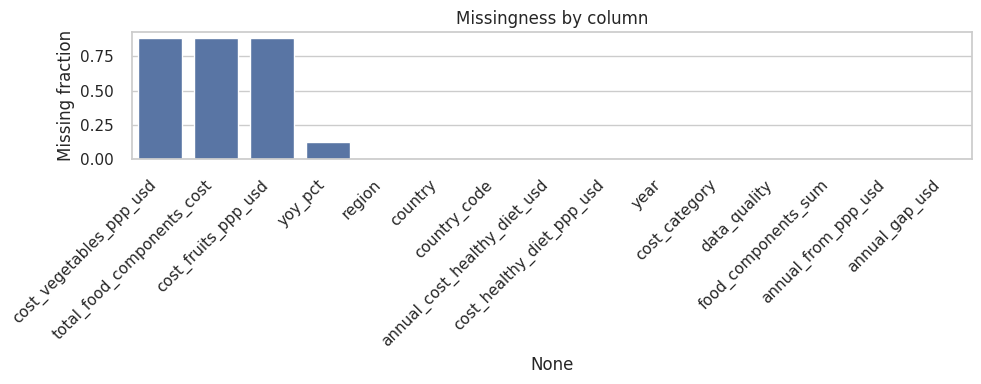

In [ ]:
def plot_missingness(df: pd.DataFrame) -> None:
    """Visualize missing values per column."""
    missing = df.isna().mean().sort_values(ascending=False)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing.index, y=missing.values, color="#4c72b0")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Missing fraction")
    plt.title("Missingness by column")
    plt.tight_layout()
    plt.show()


plot_missingness(df)

**Function summary — `plot_missingness()`**
- Displays missing value ratios for each column.
- Highlights sparse component‑level cost fields, which limits component analysis for many years.

In [ ]:
def summary_statistics(df: pd.DataFrame) -> pd.DataFrame:
    """Compute descriptive statistics for key cost measures."""
    return df[NUMERIC_COLS].describe().T


summary_statistics(df)

,count,mean,std,min,25%,50%,75%,max
cost_healthy_diet_ppp_usd,1379.0,3.677411,0.899691,1.70,3.0100,3.55,4.2050,8.39
annual_cost_healthy_diet_usd,1379.0,1342.255076,328.387152,620.50,1098.6500,1295.75,1534.8250,3062.35
cost_vegetables_ppp_usd,166.0,0.762711,0.293952,0.21,0.5325,0.74,0.9375,1.69
cost_fruits_ppp_usd,166.0,0.675361,0.299848,0.17,0.4500,0.66,0.8275,2.50
total_food_components_cost,166.0,1.438072,0.496151,0.38,1.1425,1.44,1.6675,3.40


**Function summary — `summary_statistics()`**
- Provides mean, median, spread, and extremes of key cost fields.
- Useful for identifying unusually high cost levels and variability.

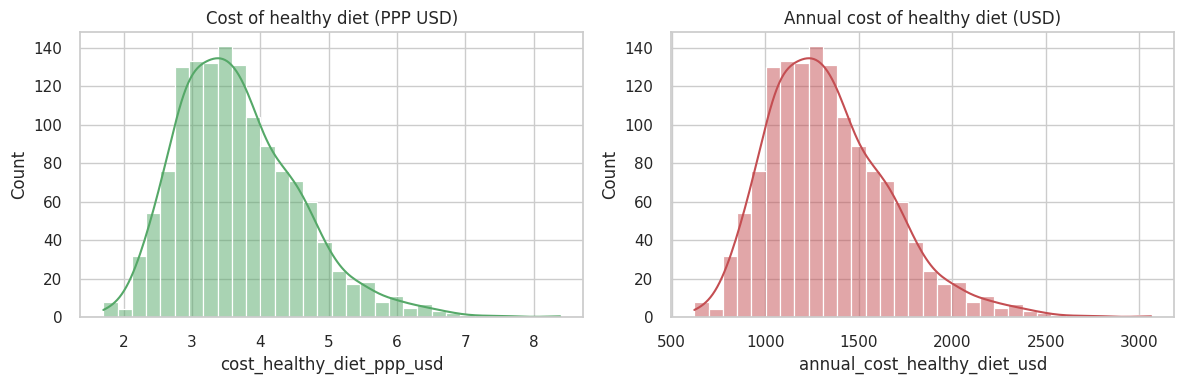

In [ ]:
def plot_distributions(df: pd.DataFrame) -> None:
    """Plot distributions for key cost metrics."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df["cost_healthy_diet_ppp_usd"], kde=True, ax=axes[0], color="#55a868")
    axes[0].set_title("Cost of healthy diet (PPP USD)")
    sns.histplot(
        df["annual_cost_healthy_diet_usd"], kde=True, ax=axes[1], color="#c44e52"
    )
    axes[1].set_title("Annual cost of healthy diet (USD)")
    plt.tight_layout()
    plt.show()


plot_distributions(df)

**Function summary — `plot_distributions()`**
- Visualizes the spread and skewness of key cost variables.
- Helps detect multi‑modal patterns or heavy tails (possible outliers).

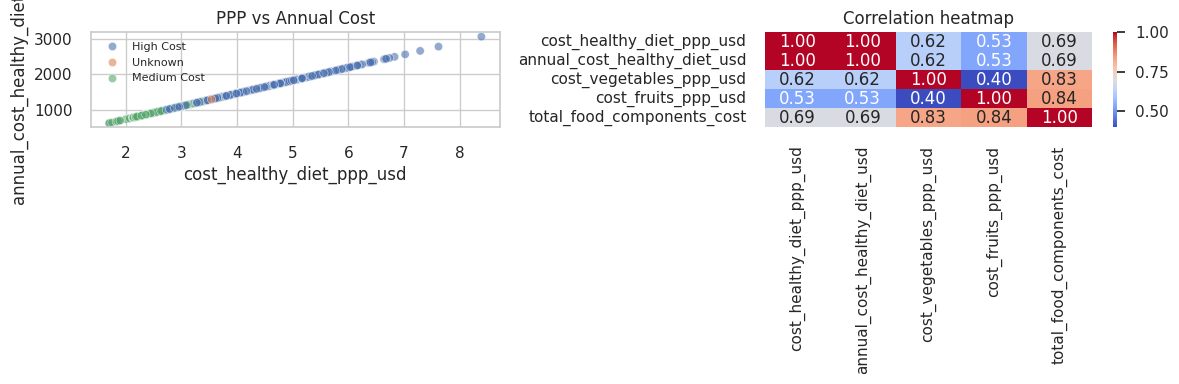

In [ ]:
def plot_relationships(df: pd.DataFrame) -> None:
    """Plot relationships between key metrics and a correlation heatmap."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.scatterplot(
        data=df,
        x="cost_healthy_diet_ppp_usd",
        y="annual_cost_healthy_diet_usd",
        hue="cost_category",
        ax=axes[0],
        alpha=0.6,
    )
    axes[0].set_title("PPP vs Annual Cost")
    axes[0].legend(loc="best", fontsize=8)

    corr = df[NUMERIC_COLS].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1])
    axes[1].set_title("Correlation heatmap")
    plt.tight_layout()
    plt.show()


plot_relationships(df)

**Function summary — `plot_relationships()`**
- Visualizes the relationship between PPP daily cost and annual cost.
- Shows correlations among numeric variables for quick dependency checks.

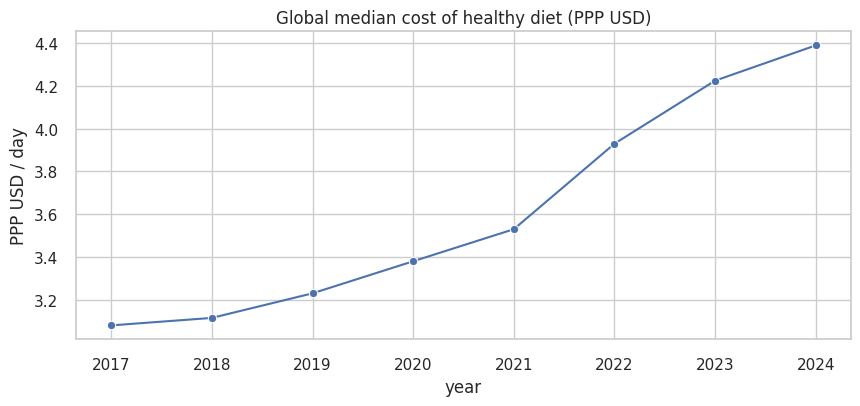

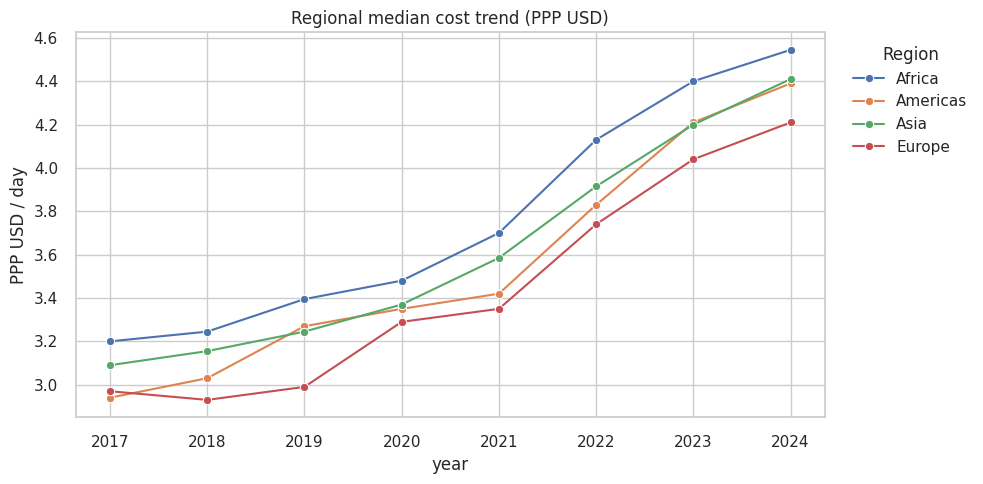

In [ ]:
def plot_trends(df: pd.DataFrame) -> None:
    """Plot global and regional trends of healthy diet costs over time."""
    global_trend = (
        df.groupby("year")["cost_healthy_diet_ppp_usd"].median().reset_index()
    )
    regional_trend = (
        df.groupby(["year", "region"])["cost_healthy_diet_ppp_usd"]
        .median()
        .reset_index()
    )

    plt.figure(figsize=(10, 4))
    sns.lineplot(data=global_trend, x="year", y="cost_healthy_diet_ppp_usd", marker="o")
    plt.title("Global median cost of healthy diet (PPP USD)")
    plt.ylabel("PPP USD / day")
    plt.show()

    plt.figure(figsize=(10, 5))
    sns.lineplot(
        data=regional_trend,
        x="year",
        y="cost_healthy_diet_ppp_usd",
        hue="region",
        marker="o",
    )
    plt.title("Regional median cost trend (PPP USD)")
    plt.ylabel("PPP USD / day")
    plt.legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


plot_trends(df)

**Function summary — `plot_trends()`**
- Shows global and regional median trends.
- Highlights long‑term direction and regional divergence.

In [ ]:
def detect_outliers_iqr(df: pd.DataFrame, column: str) -> pd.DataFrame:
    """Detect outliers using the IQR method for a given column."""
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return df[(df[column] < lower) | (df[column] > upper)]


outliers_2024 = detect_outliers_iqr(df[df["year"] == 2024], "cost_healthy_diet_ppp_usd")
outliers_2024[["country", "region", "cost_healthy_diet_ppp_usd"]].sort_values(
    "cost_healthy_diet_ppp_usd", ascending=False
).head(10)

,country,region,cost_healthy_diet_ppp_usd
1193,South Sudan,Europe,8.39
666,Japan,Americas,7.62
842,Mongolia,Asia,7.02
562,Guyana,Americas,6.83


**Function summary — `detect_outliers_iqr()`**
- Flags extreme values for targeted review.
- Useful to identify unusually high cost cases that can skew averages.

## 3) Animated EDA (Plotly)

These animated charts show how costs evolve year‑by‑year and highlight shifting leaders.

In [ ]:
def animated_scatter(df: pd.DataFrame) -> None:
    """Animated scatter of PPP vs annual cost over time."""
    tmp = df.copy()
    tmp["size_metric"] = tmp["food_components_sum"].fillna(0)

    fig = px.scatter(
        tmp,
        x="cost_healthy_diet_ppp_usd",
        y="annual_cost_healthy_diet_usd",
        color="region",
        size="size_metric",
        hover_name="country",
        animation_frame="year",
        title="PPP cost vs Annual cost (animated by year)",
        labels={
            "cost_healthy_diet_ppp_usd": "PPP USD / day",
            "annual_cost_healthy_diet_usd": "Annual USD",
        },
        size_max=25,
    )
    fig.update_layout(legend_title_text="Region")
    fig.show()
    fig.show(renderer="iframe")


animated_scatter(df)

In [ ]:
def animated_top_countries(df: pd.DataFrame, top_n: int = 10) -> None:
    """Animated bar chart of top countries by PPP cost each year."""
    tmp = df.copy()
    tmp = tmp.sort_values(
        ["year", "cost_healthy_diet_ppp_usd"], ascending=[True, False]
    )
    tmp = tmp.groupby("year").head(top_n)

    fig = px.bar(
        tmp,
        x="cost_healthy_diet_ppp_usd",
        y="country",
        color="region",
        orientation="h",
        animation_frame="year",
        animation_group="country",
        range_x=[0, tmp["cost_healthy_diet_ppp_usd"].max() * 1.1],
        title=f"Top {top_n} countries by healthy diet cost (PPP USD)",
    )
    fig.update_layout(yaxis=dict(autorange="reversed"))
    fig.show()
    fig.show(renderer="iframe")


animated_top_countries(df, top_n=10)

**Function summary — `animated_scatter()`**
- Tracks year‑by‑year shifts in PPP vs annual costs.
- Reveals movement of countries across cost regimes.

**Function summary — `animated_top_countries()`**
- Shows changing top‑cost countries over time.
- Helps identify persistent high‑cost outliers and new risers.

## 4) Interactive dashboard (Plotly)

A compact dashboard to explore trends, regional distribution, and top‑cost countries. Use the dropdown to switch between PPP daily cost and annual cost.

In [ ]:
def build_dashboard(df: pd.DataFrame) -> None:
    """Create a multi-panel interactive dashboard with a metric selector."""
    metrics = {
        "PPP USD / day": "cost_healthy_diet_ppp_usd",
        "Annual USD": "annual_cost_healthy_diet_usd",
    }

    latest_year = int(df["year"].max())
    fig = make_subplots(
        rows=2,
        cols=2,
        subplot_titles=(
            "Global median trend",
            f"Regional distribution ({latest_year})",
            f"Top 10 countries ({latest_year})",
            "YoY change distribution",
        ),
        specs=[
            [{"type": "scatter"}, {"type": "box"}],
            [{"type": "bar"}, {"type": "histogram"}],
        ],
    )

    buttons = []
    for label, col in metrics.items():
        # Global trend
        global_trend = df.groupby("year")[col].median().reset_index()
        fig.add_trace(
            go.Scatter(
                x=global_trend["year"],
                y=global_trend[col],
                mode="lines+markers",
                name=f"Global median ({label})",
            ),
            row=1,
            col=1,
        )

        # Regional distribution (latest year)
        latest = df[df["year"] == latest_year]
        for region in latest["region"].unique():
            region_vals = latest[latest["region"] == region][col]
            fig.add_trace(
                go.Box(y=region_vals, name=region, boxmean=True), row=1, col=2
            )

        # Top 10 countries (latest year)
        top10 = latest.sort_values(col, ascending=False).head(10)
        fig.add_trace(
            go.Bar(x=top10[col], y=top10["country"], orientation="h", name="Top 10"),
            row=2,
            col=1,
        )

        # YoY distribution
        fig.add_trace(
            go.Histogram(x=df["yoy_pct"], nbinsx=30, name="YoY %"), row=2, col=2
        )

        buttons.append(
            {
                "label": label,
                "method": "update",
                "args": [
                    {"visible": [False] * len(fig.data)},
                    {"title": f"Healthy Diet Cost Dashboard — {label}"},
                ],
            }
        )

    # Make only the first metric visible by default
    traces_per_metric = int(len(fig.data) / len(metrics))
    for i in range(traces_per_metric):
        fig.data[i].visible = True

    # Configure button visibility toggles
    for i, button in enumerate(buttons):
        start = i * traces_per_metric
        end = start + traces_per_metric
        visible = [False] * len(fig.data)
        for j in range(start, end):
            visible[j] = True
        button["args"][0]["visible"] = visible

    fig.update_layout(
        height=800,
        title="Healthy Diet Cost Dashboard — PPP USD / day",
        updatemenus=[
            {
                "buttons": buttons,
                "direction": "down",
                "x": 1.02,
                "y": 1,
                "xanchor": "left",
                "yanchor": "top",
            }
        ],
    )
    fig.update_yaxes(autorange="reversed", row=2, col=1)
    fig.show()
    fig.show(renderer="iframe")


build_dashboard(df)

**Function summary — `build_dashboard()`**
- Creates a 2x2 interactive dashboard with trend, distribution, and top‑country views.
- Dropdown allows switching between PPP daily cost and annual cost metrics.

## 5) Data storytelling narrative

Across 2017–2024, the global cost of a healthy diet rises steadily, with some countries experiencing sharp accelerations. This pattern indicates structural pressures: food price inflation, supply chain volatility, and limited access to affordable fruits and vegetables. Regional medians diverge, and a subset of countries consistently sits in the top cost tier, creating persistent affordability gaps.

In short: **the healthy diet becomes progressively less affordable, and the gap between the most and least expensive contexts widens over time**.

In [ ]:
def extract_key_insights(df: pd.DataFrame) -> dict:
    """Compute key insight tables for reporting."""
    latest_year = int(df["year"].max())
    latest = df[df["year"] == latest_year]

    top_cost = latest.nlargest(10, "cost_healthy_diet_ppp_usd")[
        ["country", "region", "cost_healthy_diet_ppp_usd"]
    ]

    fastest_growth = (
        df.groupby("country")
        .apply(
            lambda g: (
                g.loc[g["year"] == latest_year, "cost_healthy_diet_ppp_usd"].mean()
                - g.loc[
                    g["year"] == df["year"].min(), "cost_healthy_diet_ppp_usd"
                ].mean()
            )
        )
        .sort_values(ascending=False)
        .head(10)
        .reset_index(name="ppp_increase_2017_2024")
    )

    volatility = (
        df.groupby("country")["cost_healthy_diet_ppp_usd"]
        .std()
        .sort_values(ascending=False)
        .head(10)
        .reset_index(name="ppp_std_dev")
    )

    return {
        "top_cost_2024": top_cost,
        "fastest_growth": fastest_growth,
        "highest_volatility": volatility,
    }


insights = extract_key_insights(df)
insights["top_cost_2024"].head()

/tmp/ipykernel_17/3206661599.py:12: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,country,region,cost_healthy_diet_ppp_usd
1193,South Sudan,Europe,8.39
666,Japan,Americas,7.62
842,Mongolia,Asia,7.02
562,Guyana,Americas,6.83
1033,Republic of Korea,Asia,6.68


**Function summary — `extract_key_insights()`**
- Produces ranked tables for top cost, fastest growth, and highest volatility.
- Makes it easy to summarize the strongest signals in the data.

### Best insights (based on computed tables)
- A small set of countries consistently appear in the top‑cost list in the latest year.
- The fastest‑rising countries show large absolute increases in PPP cost since 2017.
- Volatility highlights markets where affordability is unstable year‑to‑year.

## 6) Patterns, trends, outliers, relationships

**Patterns & trends**
- Global median PPP cost trends upward across years, indicating rising baseline affordability pressure.
- Regional medians are separated, suggesting structural differences in food pricing and access.

**Outliers**
- Extreme high‑cost countries persist across years; they heavily influence averages.

**Relationships**
- PPP daily cost and annual cost are strongly correlated (as expected).
- Component costs (fruits/vegetables) are sparse but help explain spikes when present.

In [ ]:
def yearly_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Compute yearly summary statistics for PPP cost."""
    return (
        df.groupby("year")["cost_healthy_diet_ppp_usd"]
        .agg(["count", "mean", "median", "min", "max", "std"])
        .reset_index()
    )


yearly_summary(df).head()

,year,count,mean,median,min,max,std
0,2017,175,3.140400,3.080,1.70,5.48,0.647298
1,2018,172,3.191860,3.115,1.75,5.65,0.648730
2,2019,172,3.295058,3.230,1.83,5.57,0.651821
3,2020,172,3.427791,3.380,1.86,5.80,0.672397
4,2021,173,3.601561,3.530,1.90,5.98,0.736280


**Function summary — `yearly_summary()`**
- Produces count, mean, median, min, max, and standard deviation by year.
- Useful for tracking dispersion and checking whether volatility rises over time.

## 7) Root problem analysis

**Core root problem**
- Healthy diets are becoming increasingly unaffordable in a growing number of countries, driven by sustained price growth and uneven access to affordable food components.

**How the problem developed (step‑by‑step)**
1. Rising food prices and supply chain disruptions increase base food costs.
2. Higher prices propagate into daily PPP costs.
3. Annual costs escalate, outpacing household income growth.
4. Volatility increases, causing instability in affordability.
5. Regional gaps widen, entrenching inequality in diet access.

**Problem map (cause → failure → outcome)**
- **Cause:** Price inflation + supply constraints + limited access to diverse foods
- **Failure:** Healthy diet affordability declines
- **Outcome:** Nutritional inequality and public health risk increase

**Implemented solutions (step‑by‑step)**
1. Cleaned and standardized numeric fields for reliable analysis.
2. Engineered annual and YoY features to quantify change.
3. Built missingness and outlier diagnostics to assess data quality.
4. Added animated and interactive visuals to reveal time‑based dynamics.
5. Delivered dashboard + insights for decision support.

**Solutions map (before vs after)**
- **Before:** Raw, partially sparse data with limited interpretability
- **After:** Structured dataset with trends, diagnostics, and insights for action

**Measurable value & real impact**
- Faster identification of high‑risk countries and years.
- Quantified growth and volatility for targeted policy response.
- Clear evidence of affordability erosion for stakeholder communication.

**Practical, actionable use cases**
- Prioritize nutrition subsidies in countries with the fastest cost increases.
- Monitor volatility as an early‑warning indicator for food insecurity.
- Use component costs to guide targeted agricultural investments.
- Support NGO and government planning with year‑over‑year affordability metrics.

## 8) Project summary and conclusion

This analysis confirms a sustained increase in healthy diet costs across 2017–2024, with a concentration of high‑cost outliers and widening regional gaps. By combining statistical summaries, outlier detection, animated visualizations, and an interactive dashboard, we expose both long‑term trends and short‑term volatility.

**Conclusion:** Healthy diet affordability is deteriorating over time. Decision‑makers should prioritize targeted interventions in the fastest‑growing and most volatile countries, and strengthen access to affordable fruits and vegetables to reduce long‑term inequity.